In [1]:
!pip install torch

In [2]:
from FmowManager import FmowManager

manager = FmowManager()


print("\n--- STEP 1: Total Dataset ---")
total_df = manager.get_dataset()

print("\n--- STEP 2: Divide into preDF (2002-2013) and postDF (2016-2017) ---")
preDF, postDF = manager.divide(total_df)


# Find the 25 most popular classes in preDF
top_25_classes = preDF['category'].value_counts().nlargest(25).index.tolist()
print(f"Top 25 classes identified: {top_25_classes}")

# Filter preDF to only include these top 25 classes
preDF_top25 = preDF[preDF['category'].isin(top_25_classes)].copy()

# Create the mapping required for the TorchDataset
class_to_idx = {cls_name: idx for idx, cls_name in enumerate(top_25_classes)}

print("\n--- STEP 3: Sample 1100 images per class in preDF (top 25 classes) ---")
preDF_sampled = manager.sample_dataset(
        preDF_top25,
        category_col='category',
        samples_per_class=1100,
        random_state=42
    )

print("\n--- STEP 4: Sample 500 images per class in postDF, shuffle, create/order by concepts ---")
    # Filter postDF to include the SAME 25 classes
postDF_top25 = postDF[postDF['category'].isin(top_25_classes)].copy()

postDF_sampled = manager.sample_dataset(
        postDF_top25,
        category_col='category',
        samples_per_class=500,
        random_state=42
    )


--- STEP 1: Total Dataset ---


C:\Users\kevin\PycharmProjects\master_thesis\.venv\Lib\site-packages\outdated\__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version



--- STEP 2: Divide into preDF (2002-2013) and postDF (2016-2017) ---
Splitting dataset temporally...
-> 2002-2013 Dataset: 148790 images
-> 2016-2017 Dataset: 216959 images
Top 25 classes identified: ['recreational_facility', 'crop_field', 'place_of_worship', 'parking_lot_or_garage', 'military_facility', 'educational_institution', 'multi-unit_residential', 'ground_transportation_station', 'swimming_pool', 'tower', 'barn', 'single-unit_residential', 'shopping_mall', 'smokestack', 'fountain', 'hospital', 'gas_station', 'road_bridge', 'railway_bridge', 'office_building', 'amusement_park', 'fire_station', 'water_treatment_facility', 'stadium', 'race_track']

--- STEP 3: Sample 1100 images per class in preDF (top 25 classes) ---
--- Sampling 1100 images per class ---

--- STEP 4: Sample 500 images per class in postDF, shuffle, create/order by concepts ---
--- Sampling 500 images per class ---


C:\Users\kevin\PycharmProjects\master_thesis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



--- STEP 5: Extracting Foundation Model Embeddings for PostDF ---
Found saved dataset at ./dino. Loading from disk...
Clustering embeddings...
Distribution of images across the new macro-classes:
concept
4    5500
3    2500
2    2500
1    1500
5     500
Name: count, dtype: int64


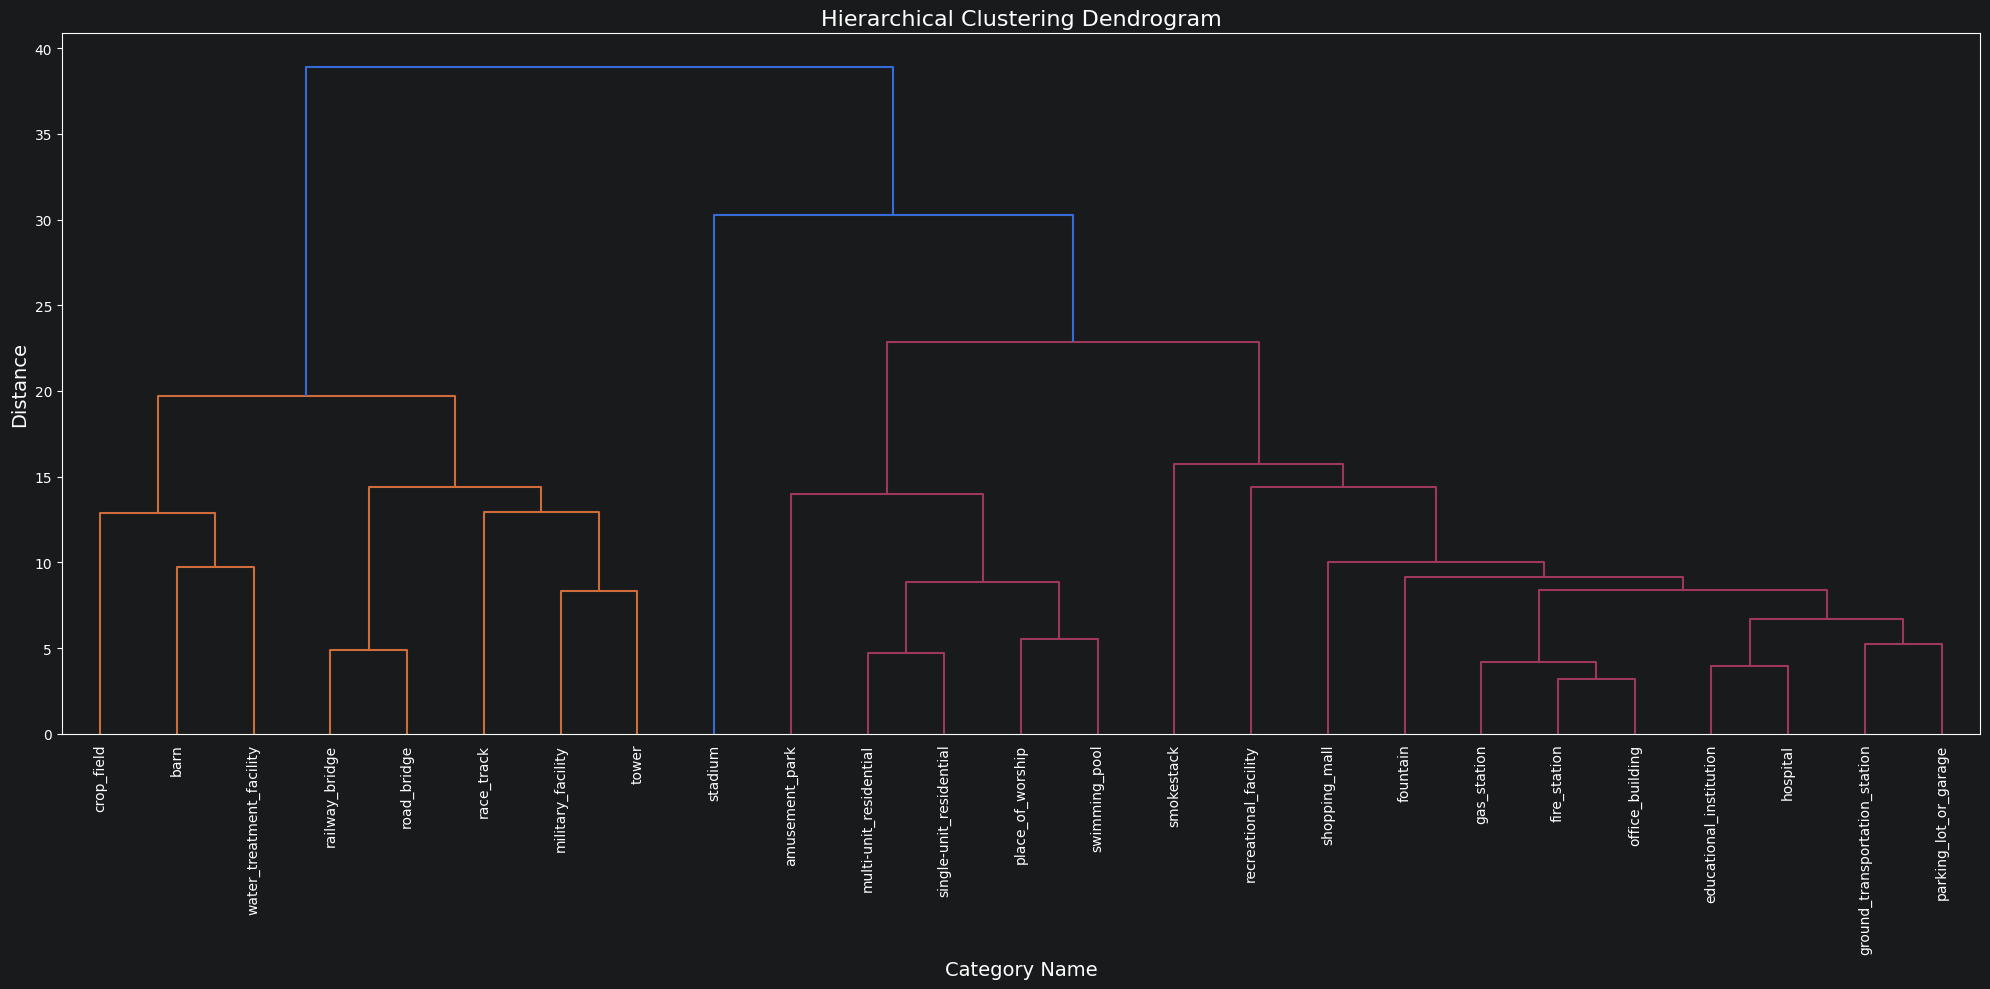

Distribution of images across the new macro-classes:
concept
Concept_0    2500
Concept_4    2500
Concept_3    2500
Concept_1    2500
Concept_2    2500
Name: count, dtype: int64


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
import matplotlib.pyplot as plt

# Assuming these are available from your modules
from TrainingManager import TrainingManager
from FoundationModel import FoundationModel
from FeatureDistillation import LinearReluDistiller
from Student import Student

# --- DATA PREPARATION COMPLETE (From your previous step) ---

# 1. Setup Transforms (ImageNet standard for ResNet18 and DINOv2)
transform_imagenet = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

training_manager = TrainingManager()
criterion = nn.CrossEntropyLoss()
num_classes = 25

print("\n--- STEP 5: Extracting Foundation Model Embeddings for PostDF ---")
fm_model = FoundationModel().to(manager.device)

# We need the embeddings explicitly calculated before the stream to simulate the offline teacher
postDF_sampled = manager.get_embeddings(
    df_sample=postDF_sampled,
    model=fm_model,
    transform_fn=transform_imagenet,
    batch_size=128,
    save_path="./dino"
)

manager.cluster_by_class(df= postDF_sampled,num_clusters=5)

# Shuffle the dataset
postDF_sampled = postDF_sampled.sample(frac=1, random_state=42).reset_index(drop=True)

# Mocking a class_to_concept mapping for demonstration (e.g., grouping into 'Urban', 'Nature', etc.)
# In reality, you'd define this based on your specific FMoW semantic groupings.
dummy_concept_mapping = {cls: (f"Concept_{(i%5)}") for i, cls in enumerate(top_25_classes)}

postDF_sampled = manager.create_concepts(postDF_sampled, dummy_concept_mapping)

    # Order by the newly created concepts
postDF_sampled = postDF_sampled.sort_values(by='concept').reset_index(drop=True)

# Free up memory before streaming
del fm_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()




 EXPERIMENT 1: PURE INFERENCE (Pretrained ImageNet)


C:\Users\kevin\PycharmProjects\master_thesis\.venv\Lib\site-packages\torchvision\models\_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(
Stream (Inference Only: True):   0%|          | 0/12500 [00:00<?, ?it/s]


--- DRIFT DETECTED: Transition da Concept 0 a Concept Concept_0 ---


Stream (Inference Only: True):  20%|██        | 2508/12500 [00:53<03:37, 45.87it/s]


--- DRIFT DETECTED: Transition da Concept Concept_0 a Concept Concept_1 ---


...


--- DRIFT DETECTED: Transition da Concept Concept_2 a Concept Concept_3 ---


Stream (Inference Only: False):  80%|████████  | 10010/12500 [14:18<05:46,  7.19it/s]


--- DRIFT DETECTED: Transition da Concept Concept_3 a Concept Concept_4 ---


Stream (Inference Only: False): 100%|██████████| 12500/12500 [17:54<00:00, 11.63it/s]


--- Fine Stream | Accuratezza Finale Concept Concept_4: 24.28% ---

--- STEP 6: Plotting Comparison ---


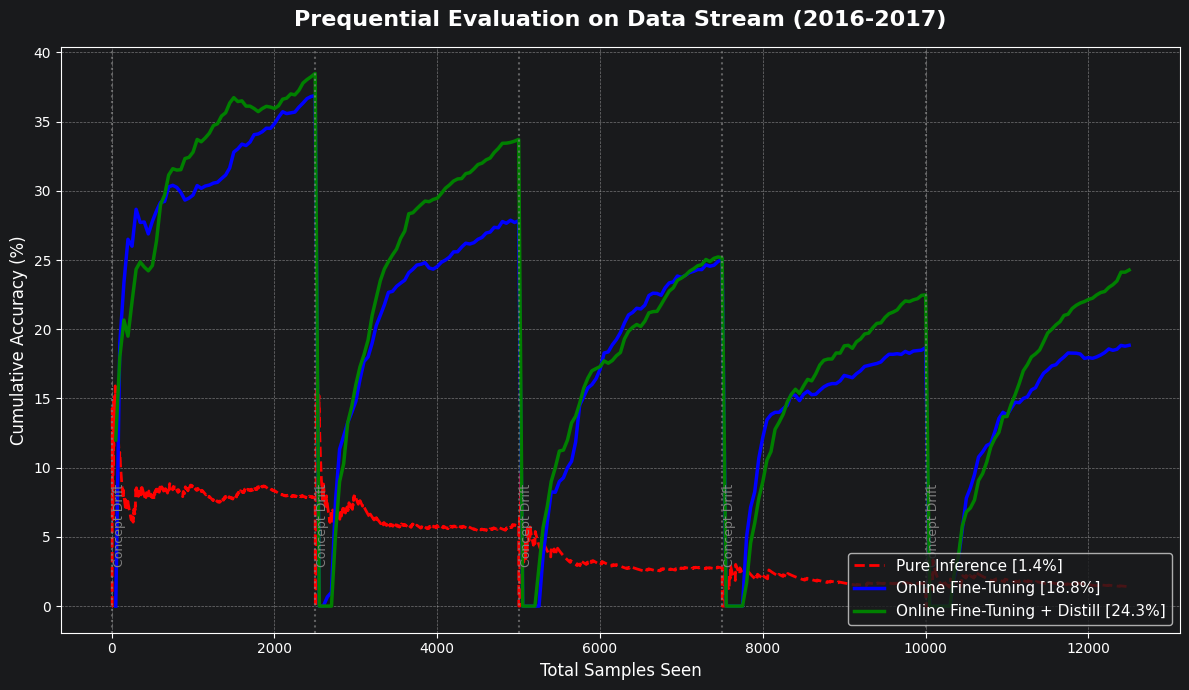

In [4]:

print("\n=======================================================")
print(" EXPERIMENT 1: PURE INFERENCE (Pretrained ImageNet)")
print("=======================================================")
# Initialize a fresh pretrained student
student_inf = Student(numberOfClasses=num_classes, pretrained=True)

acc_inf, hist_inf = training_manager.train_online(
    model=student_inf,
    df=postDF_sampled,
    criterion=criterion,
    optimizer=None, # No optimizer needed for inference
    get_input_fn=manager.get_input,
    transform_fn=transform_imagenet,
    class_to_idx=class_to_idx,
    inference_only=True, # <-- INFERENCE ONLY FLAG
    num_epochs_per_batch=3
)


print("\n=======================================================")
print(" EXPERIMENT 2: ONLINE FINE-TUNING")
print("=======================================================")
# Initialize a fresh pretrained student
student_ft = Student(numberOfClasses=num_classes, pretrained=True)
optimizer_ft = optim.Adam(student_ft.parameters(), lr=1e-3)

acc_ft, hist_ft = training_manager.train_online(
    model=student_ft,
    df=postDF_sampled,
    criterion=criterion,
    optimizer=optimizer_ft,
    get_input_fn=manager.get_input,
    transform_fn=transform_imagenet,
    class_to_idx=class_to_idx,
    inference_only=False, # <-- TRAINING ACTIVATED
    distillator=None,      # <-- NO DISTILLATION
    num_epochs_per_batch=3
)


print("\n=======================================================")
print(" EXPERIMENT 3: ONLINE FINE-TUNING + DISTILLATION")
print("=======================================================")
# Initialize a fresh pretrained student
student_dist = Student(numberOfClasses=num_classes, pretrained=True)

# DINOv2 ViT-Base has an output dimension of 768. ResNet18 feature output is 512.
distillator = LinearReluDistiller(dimFeatureStudent=512, dimFeatureTeacher=768)

optimizer_dist = optim.Adam([
    {'params': student_dist.parameters(), 'lr': 1e-3},
    {'params': distillator.parameters(), 'lr': 1e-2} # Often needs a slightly higher LR
])

acc_dist, hist_dist = training_manager.train_online(
    model=student_dist,
    df=postDF_sampled,
    criterion=criterion,
    optimizer=optimizer_dist,
    get_input_fn=manager.get_input,
    transform_fn=transform_imagenet,
    class_to_idx=class_to_idx,
    inference_only=False,     # <-- TRAINING ACTIVATED
    distillator=distillator,  # <-- DISTILLATION ACTIVATED
    distill_weight=1.0,
    num_epochs_per_batch=3
)


print("\n--- STEP 6: Plotting Comparison ---")
plt.figure(figsize=(12, 7))

# Plot Pure Inference
plt.plot(hist_inf['total_samples_seen'], hist_inf['cumulative_accuracy'],
         label=f"Pure Inference [{acc_inf:.1f}%]", color='red', linestyle='--', linewidth=2)

# Plot Online Fine-Tuning
plt.plot(hist_ft['total_samples_seen'], hist_ft['cumulative_accuracy'],
         label=f"Online Fine-Tuning [{acc_ft:.1f}%]", color='blue', linewidth=2.5)

# Plot Distillation
plt.plot(hist_dist['total_samples_seen'], hist_dist['cumulative_accuracy'],
         label=f"Online Fine-Tuning + Distill [{acc_dist:.1f}%]", color='green', linewidth=2.5)

# Add Drift Point markers (using the history from any run since they share the same data sequence)
for drift_pt in hist_inf['drift_points']:
    plt.axvline(x=drift_pt, color='gray', linestyle=':', alpha=0.7)
    plt.text(drift_pt + 10, plt.ylim()[0] + 5, 'Concept Drift', rotation=90, color='gray', fontsize=9)

plt.title("Prequential Evaluation on Data Stream (2016-2017)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Total Samples Seen", fontsize=12)
plt.ylabel("Cumulative Accuracy (%)", fontsize=12)
plt.legend(loc="lower right", fontsize=11, frameon=True, edgecolor='lightgray')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Clustering embeddings...
Distribution of images across the new macro-classes:
concept
4    5500
3    2500
2    2500
1    1500
5     500
Name: count, dtype: int64


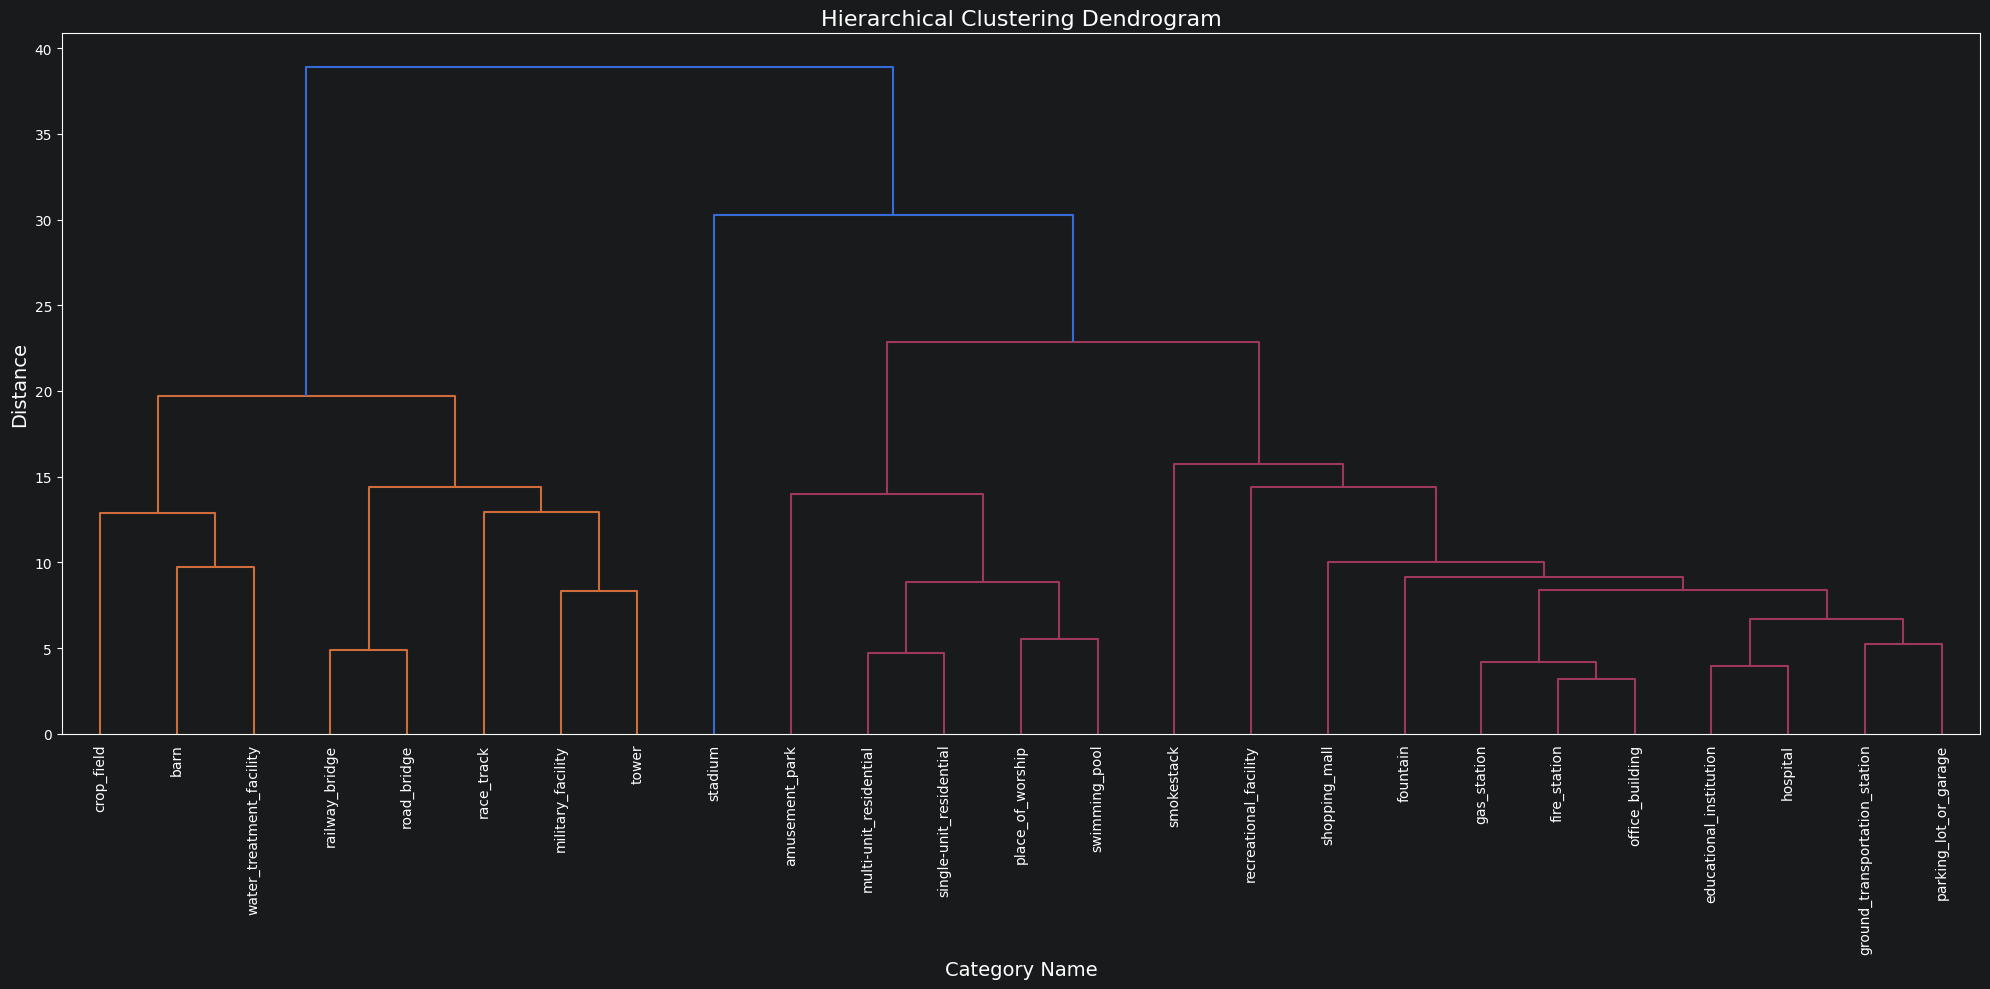

,image_index,category,embedding,concept
0,29944,barn,"[-4.040012, -1.3359542, -0.7836963, 0.4096089,...",1
1,512965,hospital,"[0.082551956, -0.84304285, 1.9205482, -0.33238...",4
2,464047,educational_institution,"[-2.4678278, -2.7820625, -0.050667614, -0.0880...",4
3,412522,recreational_facility,"[-1.5359937, 0.47433585, 0.05913657, -0.286965...",4
4,493676,amusement_park,"[-4.2548146, -0.07177829, -1.4745443, -0.02649...",3
...,...,...,...,...
12495,361921,fountain,"[-3.7709308, -1.2248641, -1.6710781, 0.9409943...",4
12496,487655,race_track,"[-1.8951288, -1.2296603, 2.704255, -0.01363974...",2
12497,97550,race_track,"[-3.6363769, 0.004877493, -1.5095189, -1.71583...",2
12498,119755,military_facility,"[-1.1525197, -0.6742908, -0.49879736, -0.11297...",2


In [5]:
manager.cluster_by_class(df= postDF_sampled,num_clusters=5)